In [2]:
from abc import ABC
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Union

import torch
import torch.nn.functional as F
from torch import nn


from dataclasses import dataclass, field
from typing import List, Optional



def normalize(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    return x / (x.norm(dim=-1, keepdim=True) + eps)

def cosine_similarity(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    a_norm = normalize(a, eps)
    b_norm = normalize(b, eps)
    return (a_norm * b_norm).sum(dim=-1)






#def entropy(tensor: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
#    prob = F.softmax(tensor, dim=-1)
#    log_prob = torch.log(prob + eps)
#    return -(prob * log_prob).sum(dim=-1)


import torch
import torch.nn.functional as F

def legacy_normalize(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    return x / (x.norm(dim=-1, keepdim=True) + eps)

def legacy_cosine_similarity(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    a_norm = legacy_normalize(a, eps)
    b_norm = legacy_normalize(b, eps)
    return (a_norm * b_norm).sum(dim=-1)


def legacy_entropy(tensor: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    prob = F.softmax(tensor, dim=-1)
    log_prob = torch.log(prob + eps)
    return -(prob * log_prob).sum(dim=-1)


def rose_score(
    x: torch.Tensor,
    need: torch.Tensor,
    relation: torch.Tensor,
    purpose: torch.Tensor,
    eps: float = 1e-8,
    full: bool = False
) -> Union[torch.Tensor, Dict[str, Union[torch.Tensor, List[torch.Tensor]]]]:
    eps = max(eps, 1e-8)
    x =         legacy_normalize(x, eps)
    need =      legacy_normalize(need, eps)
    relation =  legacy_normalize(relation, eps)
    purpose =   legacy_normalize(purpose, eps)

    # Triadic alignments
    a_n = legacy_cosine_similarity(x, need, eps)
    a_r = legacy_cosine_similarity(x, relation, eps)
    a_p = legacy_cosine_similarity(x, purpose, eps)

    # Condensed vectors
    s1 = legacy_normalize(need + relation, eps)
    s2 = legacy_normalize(need + purpose, eps)
    s3 = legacy_normalize(relation + purpose, eps)
    s4 = legacy_normalize(need - relation, eps)
    s5 = legacy_normalize(need - purpose, eps)
    s6 = legacy_normalize(relation - purpose, eps)

    # Resonance angles (cosine scores)
    r1 = legacy_cosine_similarity(x, s1, eps)
    r2 = legacy_cosine_similarity(x, s2, eps)
    r3 = legacy_cosine_similarity(x, s3, eps)
    r4 = legacy_cosine_similarity(x, s4, eps)
    r5 = legacy_cosine_similarity(x, s5, eps)
    r6 = legacy_cosine_similarity(x, s6, eps)

    # Extended resonance values
    r7 = (a_n + a_r + a_p) / 3.0                     # core triadic resonance
    r8 = x.norm(dim=-1)                              # magnitude component
    r9 = legacy_entropy(x, eps)                                  # entropy as signal complexity

    # Final ROSE value: weighted average for now
    rose = (r1 + r2 + r3 + r4 + r5 + r6 + r7 + r8 + r9) / 9.0
    if full:
        return {
            "rose": rose,
            "triadic": r7,
            "magnitude": r8,
            "entropy": r9,
            "components": [r1, r2, r3, r4, r5, r6],
            "alignment_vectors": [s1, s2, s3, s4, s5, s6]
        }
    return rose


import torch
from typing import List, Dict, Union, Optional

def rose_score_flow(
    x: torch.Tensor,
    need: torch.Tensor,
    relation: torch.Tensor,
    purpose: torch.Tensor,
    steps: int = 32,
    base_eps: float = 1e-8,
    max_eps: float = 1.0,
    retain_trace: bool = False,
    grad_scale: float = 1.0,
    detach_between_steps: bool = True
) -> Union[torch.Tensor, List[torch.Tensor]]:
    """
    Evolves a symbolic vector `x` over ROSE-space using Euler steps based on ∇ROSE(x).
    Returns final evolved vector or full trajectory if `retain_trace=True`.

    Args:
        x: token embedding [D] or batch [B, D]
        need, relation, purpose: symbolic pentachoron basis vectors [D] or [B, D]
        steps: number of flow steps
        base_eps: starting eps value
        max_eps: ending eps value (trajectory controls symbolic decay)
        retain_trace: return list of intermediate vectors
        grad_scale: velocity scale factor (Δt)
        detach_between_steps: whether to detach x between updates to prevent gradient chaining
    """
    x = x.detach().clone().requires_grad_(True)
    dt = 1.0 / steps
    trace = []

    for i in range(steps):
        eps = base_eps + i * (max_eps - base_eps) / steps
        rose = rose_score(x, need, relation, purpose, eps=eps)
        if isinstance(rose, dict):
            rose = rose["rose"]

        grad = torch.autograd.grad(rose.sum(), x, create_graph=False)[0]  # ∇ROSE(x)
        x = x + dt * grad_scale * grad

        if detach_between_steps:
            x = x.detach().clone().requires_grad_(True)

        if retain_trace:
            trace.append(x.detach().clone())

    return trace if retain_trace else x.detach()


def from_rose_dual_similarity(
    cls,
    source_vocab: List[str],
    source_embeddings: torch.Tensor,
    target_vocab: List[str],
    target_embeddings: torch.Tensor,
    need: torch.Tensor,
    relation: torch.Tensor,
    purpose: torch.Tensor,
    tau: float = 1.0,
    flat_strength: float = 1.0,
    top_k: Optional[int] = None,
    top_p: Optional[float] = None,
    use_full: bool = False
) -> "WeightedVocabMap":
    """
    Builds a WeightedVocabMap using ROSE similarity and cosine across source → target tokens.
    Uses full resonance to drive structure-aware alignment.
    """

    # Get ROSE scores for each token in source and target
    rose_src = rose_score(source_embeddings, need, relation, purpose)
    rose_tgt = rose_score(target_embeddings, need, relation, purpose)

    # Create similarity matrix based on absolute delta in rose scores
    delta = -(rose_src.unsqueeze(1) - rose_tgt.unsqueeze(0)).abs()  # [V1 x V2]

    # Optional cosine similarity blend
    src_norm = source_embeddings / source_embeddings.norm(dim=-1, keepdim=True).clamp(min=1e-6)
    tgt_norm = target_embeddings / target_embeddings.norm(dim=-1, keepdim=True).clamp(min=1e-6)
    cosine = torch.matmul(src_norm, tgt_norm.T)

    sim = (delta + cosine) / 2.0
    weights = torch.softmax(sim / tau, dim=-1) * flat_strength  # [V1 x V2]

    inst = cls()
    for i, source_token in enumerate(source_vocab):
        row = weights[i]
        scored = list(zip(target_vocab, row.tolist()))

        if top_k is not None:
            scored = sorted(scored, key=lambda x: -x[1])[:top_k]
        if top_p is not None:
            sorted_scored = sorted(scored, key=lambda x: -x[1])
            cumulative, filtered = 0.0, []
            for token, score in sorted_scored:
                cumulative += score
                if cumulative <= top_p:
                    filtered.append((token, score))
                else:
                    break
            scored = filtered

        for target_token, weight in scored:
            inst.add(source_token, target_token, float(weight))

    return inst


def rose_score_flow(
    x: torch.Tensor,
    need: torch.Tensor,
    relation: torch.Tensor,
    purpose: torch.Tensor,
    steps: int = 32,
    base_eps: float = 1e-8,
    max_eps: float = 1.0,
    retain_trace: bool = False,
    grad_scale: float = 1.0,
    detach_between_steps: bool = True
) -> Union[torch.Tensor, List[torch.Tensor]]:
    """
    Evolves a symbolic vector `x` over ROSE-space using Euler steps based on ∇ROSE(x).
    Returns final evolved vector or full trajectory if `retain_trace=True`.

    Args:
        x: token embedding [D] or batch [B, D]
        need, relation, purpose: symbolic pentachoron basis vectors [D] or [B, D]
        steps: number of flow steps
        base_eps: starting eps value
        max_eps: ending eps value (trajectory controls symbolic decay)
        retain_trace: return list of intermediate vectors
        grad_scale: velocity scale factor (Δt)
        detach_between_steps: whether to detach x between updates to prevent gradient chaining
    """
    x = x.detach().clone().requires_grad_(True)
    dt = 1.0 / steps
    trace = []

    for i in range(steps):
        eps = base_eps + i * (max_eps - base_eps) / steps
        rose = rose_score(x, need, relation, purpose, eps=eps)
        if isinstance(rose, dict):
            rose = rose["rose"]

        grad = torch.autograd.grad(rose.sum(), x, create_graph=False)[0]  # ∇ROSE(x)
        x = x + dt * grad_scale * grad

        if detach_between_steps:
            x = x.detach().clone().requires_grad_(True)

        if retain_trace:
            trace.append(x.detach().clone())

    return trace if retain_trace else x.detach()

In [3]:
# ── rose_flow_viz.ipynb or Jupyter cell ──

import torch
import matplotlib.pyplot as plt
from typing import List

# -- Load your rose_score and rose_score_flow from utils --


def visualize_rose_flow(
    vectors: List[torch.Tensor],
    labels: List[str],
    need: torch.Tensor,
    relation: torch.Tensor,
    purpose: torch.Tensor,
    steps: int = 32,
    base_eps: float = 1e-8,
    max_eps: float = 1.0,
    grad_scale: float = 1.0
):
    assert len(vectors) == len(labels)

    eps_range = torch.linspace(base_eps, max_eps, steps)
    fig, ax = plt.subplots(figsize=(10, 6))

    for i, x in enumerate(vectors):
        rose_vals = []
        for eps in eps_range:
            rose = rose_score(x, need, relation, purpose, eps=eps.item())
            rose_vals.append(rose["rose"].item() if isinstance(rose, dict) else rose.item())
        ax.plot(eps_range.numpy(), rose_vals, label=labels[i])

    ax.set_title("ROSE Score Trajectory over Eps")
    ax.set_xlabel("eps (Symbolic Degradation)")
    ax.set_ylabel("ROSE Score")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


In [5]:
import torch
import transformers


from transformers import AutoTokenizer, CLIPTokenizerFast, CLIPModel

clip_l_tokenizer: CLIPTokenizerFast = AutoTokenizer.from_pretrained("openai/clip-vit-large-patch14")
bert_beatrix_2048_tokenizer = AutoTokenizer.from_pretrained("AbstractPhil/bert-beatrix-2048", trust_remote_code=True)



I:\AIImageGen\ComfyUI\comfyui_windows_portable_sd3\new_ComfyUI_portable\ComfyUI\python_embeded\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


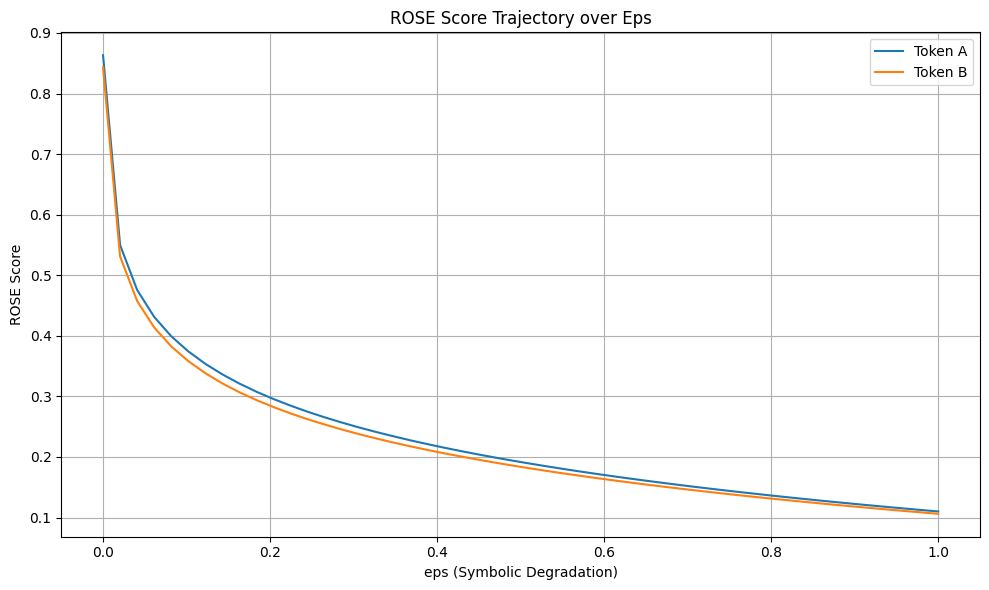

In [4]:
# Example data setup
D = 768  # or match your embedding size

torch.manual_seed(0)
x1 = torch.randn(D)
x2 = torch.randn(D)
need = torch.randn(D)
relation = torch.randn(D)
purpose = torch.randn(D)

visualize_rose_flow(
    vectors=[x1, x2],
    labels=["Token A", "Token B"],
    need=need,
    relation=relation,
    purpose=purpose,
    steps=50,
    base_eps=1e-8,
    max_eps=1.0,
    grad_scale=1.0
)


In [20]:
import torch
from transformers import AutoTokenizer, AutoModel, AutoConfig
import torch.nn.functional as F

# Load model
model_name = "AbstractPhil/bert-beatrix-2048"  # or any other model you want to use
config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(model_name, config=config)
model = AutoModel.from_pretrained(model_name, trust_remote_code=True, config=config)
model.eval()

def get_embeddings(texts):
    """Get embeddings for a list of texts."""
    encoded = tokenizer(texts, padding=True, truncation=True, return_tensors='pt')

    with torch.no_grad():
        outputs = model(**encoded)
        # Mean pooling
        embeddings = outputs.last_hidden_state.mean(dim=1)
        # Normalize
        embeddings = F.normalize(embeddings, p=2, dim=1)

    return embeddings

# Test similarity
sentences = [
    "the cat <subject1> with the dog < emotion >",
    "the cat <subject1> with the dog <emootion>",
    "the cat <subject1> with the dog <emotion>",
    "the cat <subject1> with the dog emotion",
]

embeddings = get_embeddings(sentences)
similarities = torch.mm(embeddings, embeddings.t())

print("Similarity Matrix:")
for i, sent1 in enumerate(sentences):
    for j, sent2 in enumerate(sentences):
        print(f"{similarities[i,j]:.3f} <- '{sent1}' vs '{sent2}'")

<All keys matched successfully>


Similarity Matrix:
1.000 <- 'the cat <subject1> with the dog < emotion >' vs 'the cat <subject1> with the dog < emotion >'
0.761 <- 'the cat <subject1> with the dog < emotion >' vs 'the cat <subject1> with the dog <emootion>'
0.806 <- 'the cat <subject1> with the dog < emotion >' vs 'the cat <subject1> with the dog <emotion>'
0.886 <- 'the cat <subject1> with the dog < emotion >' vs 'the cat <subject1> with the dog emotion'
0.761 <- 'the cat <subject1> with the dog <emootion>' vs 'the cat <subject1> with the dog < emotion >'
1.000 <- 'the cat <subject1> with the dog <emootion>' vs 'the cat <subject1> with the dog <emootion>'
0.636 <- 'the cat <subject1> with the dog <emootion>' vs 'the cat <subject1> with the dog <emotion>'
0.693 <- 'the cat <subject1> with the dog <emootion>' vs 'the cat <subject1> with the dog emotion'
0.806 <- 'the cat <subject1> with the dog <emotion>' vs 'the cat <subject1> with the dog < emotion >'
0.636 <- 'the cat <subject1> with the dog <emotion>' vs 'the cat 

In [21]:
import torch
from transformers import AutoTokenizer, AutoModel, AutoConfig, CLIPTokenizerFast
import torch.nn.functional as F
import numpy as np

class CrossTokenizerSimilarityTester:
    """Test BERT model with different tokenizers to see how it affects similarity."""

    def __init__(self, model_name="AbstractPhil/bert-beatrix-2048", device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

        # Load BERT model
        print(f"Loading BERT model: {model_name}")
        self.config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
        self.bert_tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name, trust_remote_code=True, config=self.config)
        self.model.to(self.device)
        self.model.eval()

        # Load CLIP tokenizer
        print("Loading CLIP tokenizer...")
        self.clip_tokenizer = CLIPTokenizerFast.from_pretrained("openai/clip-vit-base-patch32")

        # Get vocab sizes
        print(f"BERT vocab size: {self.bert_tokenizer.vocab_size}")
        print(f"CLIP vocab size: {self.clip_tokenizer.vocab_size}")
        print(f"Model vocab size: {self.config.vocab_size}")

    def tokenize_with_clip(self, texts):
        """Tokenize using CLIP tokenizer and prepare for BERT model."""
        # Tokenize with CLIP
        clip_encoded = self.clip_tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors='pt'
        )

        # CLIP uses different special tokens, so we need to handle this
        input_ids = clip_encoded['input_ids']
        attention_mask = clip_encoded['attention_mask']

        # Map CLIP tokens to valid BERT vocab range if needed
        # This is a simple modulo mapping - you might want something more sophisticated
        if self.clip_tokenizer.vocab_size > self.config.vocab_size:
            print(f"Mapping CLIP tokens from {self.clip_tokenizer.vocab_size} to {self.config.vocab_size}")
            input_ids = input_ids % self.config.vocab_size

        return {
            'input_ids': input_ids.to(self.device),
            'attention_mask': attention_mask.to(self.device)
        }

    def tokenize_with_bert(self, texts):
        """Tokenize using BERT tokenizer."""
        encoded = self.bert_tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=2048,
            return_tensors='pt'
        )
        return {k: v.to(self.device) for k, v in encoded.items()}

    def get_embeddings(self, texts, use_clip_tokenizer=False, pooling='mean', verbose=True):
        """Get embeddings using specified tokenizer."""
        # Choose tokenizer
        if use_clip_tokenizer:
            encoded = self.tokenize_with_clip(texts)
            tokenizer_name = "CLIP"
        else:
            encoded = self.tokenize_with_bert(texts)
            tokenizer_name = "BERT"

        if verbose:
            print(f"\nUsing {tokenizer_name} tokenizer:")
            print(f"Input shape: {encoded['input_ids'].shape}")
            print(f"Sample tokens: {encoded['input_ids'][0][:20].tolist()}...")

        # Get embeddings
        with torch.no_grad():
            outputs = self.model(**encoded)

            if pooling == 'mean':
                # Mean pooling
                token_embeddings = outputs.last_hidden_state
                mask = encoded['attention_mask'].unsqueeze(-1).expand(token_embeddings.size())
                masked_embeddings = token_embeddings * mask
                embeddings = masked_embeddings.sum(1) / mask.sum(1).clamp(min=1e-9)
            elif pooling == 'cls':
                # CLS token
                embeddings = outputs.last_hidden_state[:, 0]
            else:
                raise ValueError(f"Unknown pooling method: {pooling}")

            # Normalize
            embeddings = F.normalize(embeddings, p=2, dim=1)

        return embeddings

    def compare_tokenizations(self, texts, pooling='mean'):
        """Compare embeddings from both tokenizers."""
        print(f"\nComparing tokenizations for {len(texts)} texts with {pooling} pooling...")

        # Get embeddings with both tokenizers
        bert_embeddings = self.get_embeddings(texts, use_clip_tokenizer=False, pooling=pooling)
        clip_embeddings = self.get_embeddings(texts, use_clip_tokenizer=True, pooling=pooling)

        # Compute similarity matrices
        bert_similarities = torch.mm(bert_embeddings, bert_embeddings.t())
        clip_similarities = torch.mm(clip_embeddings, clip_embeddings.t())

        # Compare the embeddings themselves
        cross_similarities = torch.mm(bert_embeddings, clip_embeddings.t())

        return {
            'bert_similarities': bert_similarities,
            'clip_similarities': clip_similarities,
            'cross_similarities': cross_similarities,
            'bert_embeddings': bert_embeddings,
            'clip_embeddings': clip_embeddings
        }

    def visualize_token_differences(self, text):
        """Show how different tokenizers tokenize the same text."""
        print(f"\nTokenization comparison for: '{text}'")
        print("-" * 80)

        # BERT tokenization
        bert_tokens = self.bert_tokenizer.tokenize(text)
        bert_ids = self.bert_tokenizer.encode(text, add_special_tokens=True)
        print(f"BERT tokens ({len(bert_tokens)}): {bert_tokens}")
        print(f"BERT IDs: {bert_ids}")

        # CLIP tokenization
        clip_tokens = self.clip_tokenizer.tokenize(text)
        clip_ids = self.clip_tokenizer.encode(text, add_special_tokens=True)
        print(f"\nCLIP tokens ({len(clip_tokens)}): {clip_tokens}")
        print(f"CLIP IDs: {clip_ids}")

        # If CLIP vocab is larger, show mapped IDs
        if self.clip_tokenizer.vocab_size > self.config.vocab_size:
            mapped_ids = [id % self.config.vocab_size for id in clip_ids]
            print(f"Mapped IDs: {mapped_ids}")

def run_experiments():
    """Run comprehensive experiments comparing tokenizers."""

    # Initialize tester
    tester = CrossTokenizerSimilarityTester()

    # Test sentences with special tokens that might be handled differently
    test_sentences = [
        "The cat sits on the mat.",
        "The cat <unk> on the mat.",  # Unknown token
        "The cat [MASK] on the mat.",  # BERT mask token
        "The cat <|endoftext|> on the mat.",  # CLIP special token
        "A photo of a cat",  # CLIP-style prompt
        "cat:0.5 dog:0.3 animal:0.2",  # Token-like structure
        "The 🐱 sits on the mat.",  # Emoji
        "The cat s i t s on the mat.",  # Spaced letters
    ]

    # Show tokenization differences
    print("\n=== TOKENIZATION DIFFERENCES ===")
    for sentence in test_sentences[:3]:
        tester.visualize_token_differences(sentence)

    # Compare similarities
    print("\n\n=== SIMILARITY COMPARISON ===")
    results = tester.compare_tokenizations(test_sentences)

    # Print similarity matrices
    print("\n--- BERT Tokenizer Similarities ---")
    for i, sent1 in enumerate(test_sentences):
        for j, sent2 in enumerate(test_sentences):
            sim = results['bert_similarities'][i, j].item()
            print(f"{sim:.3f} ", end="")
        print(f" <- {sent1[:30]}...")

    print("\n--- CLIP Tokenizer Similarities ---")
    for i, sent1 in enumerate(test_sentences):
        for j, sent2 in enumerate(test_sentences):
            sim = results['clip_similarities'][i, j].item()
            print(f"{sim:.3f} ", end="")
        print(f" <- {sent1[:30]}...")

    print("\n--- Cross-Tokenizer Similarities (BERT vs CLIP) ---")
    print("How similar are embeddings when using different tokenizers on same text:")
    for i, sent in enumerate(test_sentences):
        sim = results['cross_similarities'][i, i].item()
        print(f"{sim:.3f} <- '{sent}'")

    # Test robustness to tokenization
    print("\n\n=== ROBUSTNESS TEST ===")
    robustness_tests = [
        ("Normal spacing", ["The cat sat on the mat."]),
        ("Extra spaces", ["The  cat   sat    on     the      mat."]),
        ("Special tokens", ["The <cat> sat on the <mat>."]),
        ("Mixed case", ["THE CAT SAT ON THE MAT."]),
        ("Subword splits", ["The c a t sat on the m a t."]),
    ]

    for test_name, sentences in robustness_tests:
        print(f"\n{test_name}:")
        results = tester.compare_tokenizations(sentences)

        # Get embedding from original sentence for comparison
        original_bert = tester.get_embeddings(["The cat sat on the mat."], use_clip_tokenizer=False, verbose=False)
        original_clip = tester.get_embeddings(["The cat sat on the mat."], use_clip_tokenizer=True, verbose=False)

        # Compare with test sentence
        bert_sim = F.cosine_similarity(original_bert, results['bert_embeddings']).item()
        clip_sim = F.cosine_similarity(original_clip, results['clip_embeddings']).item()

        print(f"  BERT similarity to original: {bert_sim:.3f}")
        print(f"  CLIP similarity to original: {clip_sim:.3f}")
        print(f"  Difference: {abs(bert_sim - clip_sim):.3f}")

def test_clip_style_prompts():
    """Test CLIP-style prompts with BERT."""
    print("\n\n=== CLIP-STYLE PROMPT TESTING ===")

    tester = CrossTokenizerSimilarityTester()

    # CLIP-style prompts
    clip_prompts = [
        "A photo of a cat",
        "A photo of a dog",
        "A drawing of a cat",
        "A painting of a cat",
        "An image of a cat",
        "cat",
        "A cat",
        "The cat",
    ]

    print("\nTesting how BERT handles CLIP-style prompts...")
    results = tester.compare_tokenizations(clip_prompts)

    # Find which prompts are most similar
    print("\nMost similar prompt pairs (BERT tokenizer):")
    similarities = results['bert_similarities']
    for i in range(len(clip_prompts)):
        for j in range(i+1, len(clip_prompts)):
            sim = similarities[i, j].item()
            if sim > 0.9:
                print(f"{sim:.3f}: '{clip_prompts[i]}' <-> '{clip_prompts[j]}'")

    print("\nMost similar prompt pairs (CLIP tokenizer):")
    similarities = results['clip_similarities']
    for i in range(len(clip_prompts)):
        for j in range(i+1, len(clip_prompts)):
            sim = similarities[i, j].item()
            if sim > 0.9:
                print(f"{sim:.3f}: '{clip_prompts[i]}' <-> '{clip_prompts[j]}'")

if __name__ == "__main__":
    # Run main experiments
    run_experiments()

    # Run CLIP-style prompt tests
    test_clip_style_prompts()

Loading BERT model: AbstractPhil/bert-beatrix-2048


<All keys matched successfully>


Loading CLIP tokenizer...
BERT vocab size: 30522
CLIP vocab size: 49408
Model vocab size: 30592

=== TOKENIZATION DIFFERENCES ===

Tokenization comparison for: 'The cat sits on the mat.'
--------------------------------------------------------------------------------
BERT tokens (7): ['the', 'cat', 'sits', 'on', 'the', 'mat', '.']
BERT IDs: [101, 1996, 4937, 7719, 2006, 1996, 13523, 1012, 102]

CLIP tokens (7): ['the</w>', 'cat</w>', 'sits</w>', 'on</w>', 'the</w>', 'mat</w>', '.</w>']
CLIP IDs: [49406, 518, 2368, 12726, 525, 518, 9063, 269, 49407]
Mapped IDs: [18814, 518, 2368, 12726, 525, 518, 9063, 269, 18815]

Tokenization comparison for: 'The cat <unk> on the mat.'
--------------------------------------------------------------------------------
BERT tokens (10): ['the', 'cat', '<', 'un', '##k', '>', 'on', 'the', 'mat', '.']
BERT IDs: [101, 1996, 4937, 1026, 4895, 2243, 1028, 2006, 1996, 13523, 1012, 102]

CLIP tokens (9): ['the</w>', 'cat</w>', '<</w>', 'unk</w>', '></w>', 'on</w>

<All keys matched successfully>


Loading CLIP tokenizer...
BERT vocab size: 30522
CLIP vocab size: 49408
Model vocab size: 30592

Testing how BERT handles CLIP-style prompts...

Comparing tokenizations for 8 texts with mean pooling...

Using BERT tokenizer:
Input shape: torch.Size([8, 7])
Sample tokens: [101, 1037, 6302, 1997, 1037, 4937, 102]...
Mapping CLIP tokens from 49408 to 30592

Using CLIP tokenizer:
Input shape: torch.Size([8, 7])
Sample tokens: [18814, 320, 1125, 539, 320, 2368, 18815]...

Most similar prompt pairs (BERT tokenizer):
0.914: 'A photo of a cat' <-> 'A drawing of a cat'
0.915: 'A photo of a cat' <-> 'A painting of a cat'
0.939: 'A drawing of a cat' <-> 'A painting of a cat'

Most similar prompt pairs (CLIP tokenizer):
0.993: 'A photo of a cat' <-> 'A photo of a dog'
0.993: 'A photo of a cat' <-> 'A drawing of a cat'
0.993: 'A photo of a cat' <-> 'An image of a cat'
0.988: 'A photo of a cat' <-> 'cat'
0.986: 'A photo of a cat' <-> 'A cat'
0.987: 'A photo of a cat' <-> 'The cat'
0.993: 'A photo of

Loading BERT model: AbstractPhil/bert-beatrix-2048


<All keys matched successfully>


Loading CLIP tokenizer...
Found 57 special tokens

=== Analyzing Special Token Handling ===

Analyzing token: [PAD]

Analyzing token: [UNK]

Analyzing token: [CLS]

Analyzing token: [SEP]

Analyzing token: [MASK]

Analyzing token: <subject>

Analyzing token: <pose>

Analyzing token: <emotion>

Analyzing token: <surface>

Analyzing token: <lighting>

Analyzing token: <material>

Analyzing token: <accessory>

Analyzing token: <footwear>

Analyzing token: <upper_body_clothing>

Analyzing token: <hair_style>

Analyzing token: <hair_length>

Analyzing token: <headwear>

Analyzing token: <texture>

Analyzing token: <pattern>

Analyzing token: <grid>

Analyzing token: <zone>

Analyzing token: <offset>

Analyzing token: <object_left>

Analyzing token: <object_right>

Analyzing token: <relation>

Analyzing token: <intent>

Analyzing token: <style>

Analyzing token: <fabric>

Analyzing token: <jewelry>

Analyzing token: <subject1>

Analyzing token: <subject2>

Analyzing token: [SHUNT_1000000]

A

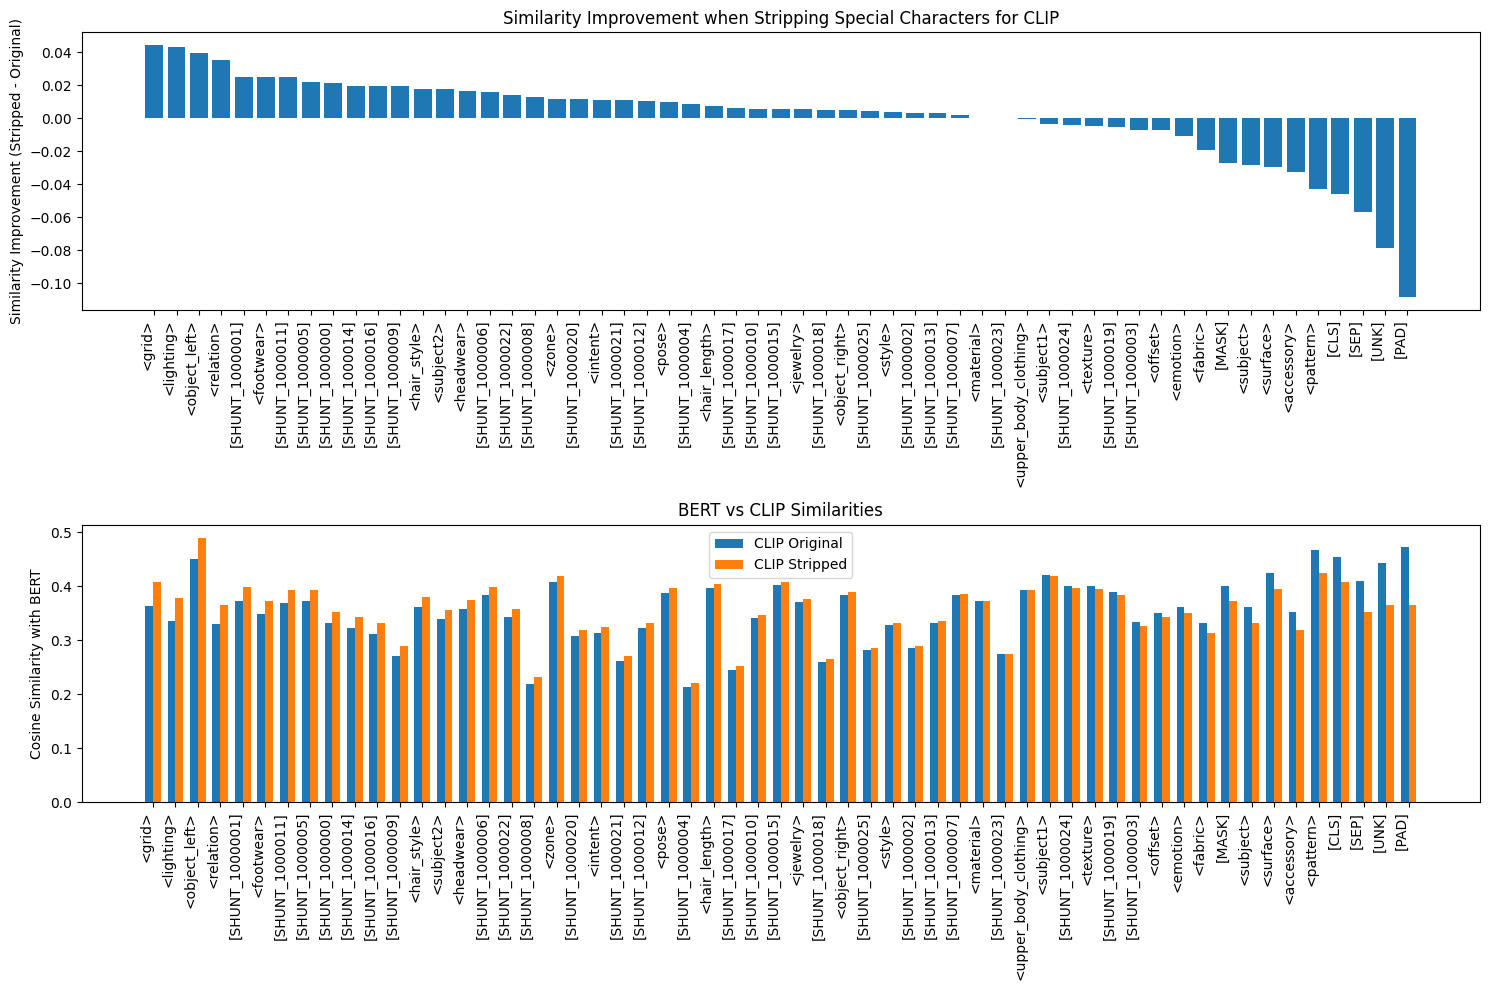


=== Analysis by Token Type ===

Standard Tokens:
  Count: 5
  Avg similarity (original): 0.436
  Avg similarity (stripped): 0.372
  Avg improvement: -0.063

Custom Tokens:
  Count: 26
  Avg similarity (original): 0.373
  Avg similarity (stripped): 0.378
  Avg improvement: 0.004

SHUNT Tokens:
  Count: 26
  Avg similarity (original): 0.320
  Avg similarity (stripped): 0.330
  Avg improvement: 0.010


C:\Users\abstr\AppData\Local\Temp\ipykernel_43312\3418043992.py:268: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  standard_tokens = results_df[results_df['token'].str.contains(r'^\[(PAD|UNK|CLS|SEP|MASK)\]$')]


In [22]:
import torch
from transformers import AutoTokenizer, AutoModel, AutoConfig, CLIPTokenizerFast
import torch.nn.functional as F
import pandas as pd
from typing import List, Dict
import re

class SpecialTokenComparison:
    """Compare how special tokens from BERT-Beatrix-2048 are handled by different tokenizers."""

    def __init__(self, bert_model_name="AbstractPhil/bert-beatrix-2048", device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

        # Load BERT model and tokenizer
        print(f"Loading BERT model: {bert_model_name}")
        self.config = AutoConfig.from_pretrained(bert_model_name, trust_remote_code=True)
        self.bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
        self.model = AutoModel.from_pretrained(bert_model_name, trust_remote_code=True)
        self.model.to(self.device)
        self.model.eval()

        # Load CLIP tokenizer
        print("Loading CLIP tokenizer...")
        self.clip_tokenizer = CLIPTokenizerFast.from_pretrained("openai/clip-vit-base-patch32")

        # Extract special tokens
        self.special_tokens = self._extract_special_tokens()
        print(f"Found {len(self.special_tokens)} special tokens")

    def _extract_special_tokens(self):
        """Extract all special tokens from the tokenizer config."""
        special_tokens = []

        # Standard special tokens
        standard_tokens = ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']

        # Custom special tokens from your config
        custom_tokens = [
            '<subject>', '<pose>', '<emotion>', '<surface>', '<lighting>',
            '<material>', '<accessory>', '<footwear>', '<upper_body_clothing>',
            '<hair_style>', '<hair_length>', '<headwear>', '<texture>', '<pattern>',
            '<grid>', '<zone>', '<offset>', '<object_left>', '<object_right>',
            '<relation>', '<intent>', '<style>', '<fabric>', '<jewelry>',
            '<subject1>', '<subject2>'
        ]

        # SHUNT tokens
        shunt_tokens = [f'[SHUNT_{1000000 + i}]' for i in range(26)]

        special_tokens = standard_tokens + custom_tokens + shunt_tokens
        return special_tokens

    def strip_special_chars(self, token):
        """Remove special characters for CLIP tokenizer."""
        # Remove < > [ ] characters
        cleaned = re.sub(r'[<>\[\]]', '', token)
        return cleaned

    def create_test_sentences(self, tokens):
        """Create test sentences for each token."""
        test_patterns = [
            "The {token} is important.",
            "A photo of {token}",
            "{token} in the image",
            "This shows {token} clearly",
            "The cat with {token}",
        ]

        sentences = {}
        for token in tokens:
            sentences[token] = [pattern.format(token=token) for pattern in test_patterns]

        return sentences

    def get_embeddings(self, texts, use_clip_tokenizer=False, strip_special=False):
        """Get embeddings using specified tokenizer."""
        if use_clip_tokenizer:
            if strip_special:
                # Strip special characters for CLIP
                texts = [re.sub(r'[<>\[\]]', '', text) for text in texts]

            encoded = self.clip_tokenizer(
                texts,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors='pt'
            )

            # Map CLIP tokens to BERT vocab space if needed
            if self.clip_tokenizer.vocab_size > self.config.vocab_size:
                encoded['input_ids'] = encoded['input_ids'] % self.config.vocab_size
        else:
            encoded = self.bert_tokenizer(
                texts,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors='pt'
            )

        encoded = {k: v.to(self.device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = self.model(**encoded)
            # Mean pooling
            embeddings = outputs.last_hidden_state.mean(dim=1)
            # Normalize
            embeddings = F.normalize(embeddings, p=2, dim=1)

        return embeddings

    def analyze_token_handling(self):
        """Analyze how each special token is handled by different tokenizers."""
        results = []

        for token in self.special_tokens:
            print(f"\nAnalyzing token: {token}")

            # Create test sentence
            test_sentence = f"The {token} is important."
            stripped_sentence = f"The {self.strip_special_chars(token)} is important."

            # Get token IDs from both tokenizers
            bert_ids = self.bert_tokenizer.encode(token, add_special_tokens=False)
            bert_tokens = self.bert_tokenizer.tokenize(token)

            # CLIP with original token
            clip_ids_original = self.clip_tokenizer.encode(token, add_special_tokens=False)
            clip_tokens_original = self.clip_tokenizer.tokenize(token)

            # CLIP with stripped token
            stripped_token = self.strip_special_chars(token)
            clip_ids_stripped = self.clip_tokenizer.encode(stripped_token, add_special_tokens=False)
            clip_tokens_stripped = self.clip_tokenizer.tokenize(stripped_token)

            # Get embeddings
            bert_emb = self.get_embeddings([test_sentence], use_clip_tokenizer=False)
            clip_emb_original = self.get_embeddings([test_sentence], use_clip_tokenizer=True, strip_special=False)
            clip_emb_stripped = self.get_embeddings([stripped_sentence], use_clip_tokenizer=True, strip_special=False)

            # Calculate similarities
            sim_bert_clip_original = F.cosine_similarity(bert_emb, clip_emb_original).item()
            sim_bert_clip_stripped = F.cosine_similarity(bert_emb, clip_emb_stripped).item()
            sim_clip_versions = F.cosine_similarity(clip_emb_original, clip_emb_stripped).item()

            results.append({
                'token': token,
                'stripped_token': stripped_token,
                'bert_token_ids': str(bert_ids),
                'bert_tokens': str(bert_tokens),
                'clip_ids_original': str(clip_ids_original),
                'clip_tokens_original': str(clip_tokens_original),
                'clip_ids_stripped': str(clip_ids_stripped),
                'clip_tokens_stripped': str(clip_tokens_stripped),
                'sim_bert_clip_original': sim_bert_clip_original,
                'sim_bert_clip_stripped': sim_bert_clip_stripped,
                'sim_clip_versions': sim_clip_versions,
                'improvement': sim_bert_clip_stripped - sim_bert_clip_original
            })

        return pd.DataFrame(results)

    def test_token_combinations(self):
        """Test how token combinations work."""
        print("\n=== Testing Token Combinations ===")

        test_cases = [
            "The <subject> with <emotion>",
            "A <style> photo of <subject1> and <subject2>",
            "<lighting> on <surface> with <material>",
            "[SHUNT_1000000] represents <intent>",
            "The subject with emotion",  # Without special tokens
            "A style photo of subject1 and subject2",  # Stripped version
        ]

        embeddings_bert = self.get_embeddings(test_cases, use_clip_tokenizer=False)
        embeddings_clip = self.get_embeddings(test_cases, use_clip_tokenizer=True, strip_special=False)
        embeddings_clip_stripped = self.get_embeddings(test_cases, use_clip_tokenizer=True, strip_special=True)

        print("\nSimilarity Matrix (BERT tokenizer):")
        sim_matrix = torch.mm(embeddings_bert, embeddings_bert.t())
        for i, case in enumerate(test_cases):
            print(f"\n{case}:")
            for j, other_case in enumerate(test_cases):
                if i != j:
                    print(f"  vs '{other_case}': {sim_matrix[i,j]:.3f}")

        print("\n\nCross-tokenizer similarities:")
        for i, case in enumerate(test_cases):
            bert_clip_sim = F.cosine_similarity(embeddings_bert[i:i+1], embeddings_clip[i:i+1]).item()
            bert_clip_stripped_sim = F.cosine_similarity(embeddings_bert[i:i+1], embeddings_clip_stripped[i:i+1]).item()
            print(f"\n{case}:")
            print(f"  BERT vs CLIP (original): {bert_clip_sim:.3f}")
            print(f"  BERT vs CLIP (stripped): {bert_clip_stripped_sim:.3f}")

    def visualize_results(self, df):
        """Create visualizations of the results."""
        import matplotlib.pyplot as plt

        # Sort by improvement
        df_sorted = df.sort_values('improvement', ascending=False)

        # Plot improvements
        plt.figure(figsize=(15, 10))

        plt.subplot(2, 1, 1)
        x = range(len(df_sorted))
        plt.bar(x, df_sorted['improvement'])
        plt.xticks(x, df_sorted['token'], rotation=90, ha='right')
        plt.ylabel('Similarity Improvement (Stripped - Original)')
        plt.title('Similarity Improvement when Stripping Special Characters for CLIP')
        plt.tight_layout()

        plt.subplot(2, 1, 2)
        width = 0.35
        x = range(len(df_sorted))
        plt.bar([i - width/2 for i in x], df_sorted['sim_bert_clip_original'], width, label='CLIP Original')
        plt.bar([i + width/2 for i in x], df_sorted['sim_bert_clip_stripped'], width, label='CLIP Stripped')
        plt.xticks(x, df_sorted['token'], rotation=90, ha='right')
        plt.ylabel('Cosine Similarity with BERT')
        plt.title('BERT vs CLIP Similarities')
        plt.legend()
        plt.tight_layout()

        plt.savefig('special_token_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()

def main():
    """Run the complete analysis."""
    analyzer = SpecialTokenComparison()

    print("\n=== Analyzing Special Token Handling ===")
    results_df = analyzer.analyze_token_handling()

    # Save results
    results_df.to_csv('special_token_analysis.csv', index=False)

    # Display summary statistics
    print("\n=== Summary Statistics ===")
    print(f"Average similarity (BERT vs CLIP original): {results_df['sim_bert_clip_original'].mean():.3f}")
    print(f"Average similarity (BERT vs CLIP stripped): {results_df['sim_bert_clip_stripped'].mean():.3f}")
    print(f"Average improvement from stripping: {results_df['improvement'].mean():.3f}")

    # Show tokens with biggest improvements
    print("\n=== Top 10 Tokens with Biggest Improvement ===")
    top_improvements = results_df.nlargest(10, 'improvement')[['token', 'stripped_token', 'improvement']]
    print(top_improvements.to_string(index=False))

    # Show tokens with worst handling
    print("\n=== Top 10 Tokens with Worst Original Handling ===")
    worst_handling = results_df.nsmallest(10, 'sim_bert_clip_original')[['token', 'sim_bert_clip_original', 'sim_bert_clip_stripped']]
    print(worst_handling.to_string(index=False))

    # Test combinations
    analyzer.test_token_combinations()

    # Create visualizations
    try:
        analyzer.visualize_results(results_df)
    except ImportError:
        print("\nMatplotlib not available for visualization")

    # Detailed analysis for specific token types
    print("\n=== Analysis by Token Type ===")

    # Group by token type
    standard_tokens = results_df[results_df['token'].str.contains(r'^\[(PAD|UNK|CLS|SEP|MASK)\]$')]
    custom_tokens = results_df[results_df['token'].str.contains(r'^<.*>$')]
    shunt_tokens = results_df[results_df['token'].str.contains(r'^\[SHUNT_')]

    for name, group in [('Standard', standard_tokens), ('Custom', custom_tokens), ('SHUNT', shunt_tokens)]:
        if len(group) > 0:
            print(f"\n{name} Tokens:")
            print(f"  Count: {len(group)}")
            print(f"  Avg similarity (original): {group['sim_bert_clip_original'].mean():.3f}")
            print(f"  Avg similarity (stripped): {group['sim_bert_clip_stripped'].mean():.3f}")
            print(f"  Avg improvement: {group['improvement'].mean():.3f}")

if __name__ == "__main__":
    main()

In [2]:
!pip uninstall transformers -y
!pip install transformers==4.36.2

Found existing installation: transformers 4.30.2
Uninstalling transformers-4.30.2:
  Successfully uninstalled transformers-4.30.2
  Using cached transformers-4.36.2-py3-none-any.whl.metadata (126 kB)
Using cached transformers-4.36.2-py3-none-any.whl (8.2 MB)
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ------------------- -------------------- 1.0/2.2 MB 25.4 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 5.9 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.13.3
    Uninstalling tokenizers-0.13.3:
      Successfully uninstalled tokenizers-0.13.3


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
animatediff 0.1.dev226+g6bf8bed requires accelerate>=0.20.3, but you have accelerate 0.19.0 which is incompatible.
animatediff 0.1.dev226+g6bf8bed requires diffusers==0.23.0, but you have diffusers 0.18.2 which is incompatible.
animatediff 0.1.dev226+g6bf8bed requires einops>=0.6.1, but you have einops 0.6.0 which is incompatible.
animatediff 0.1.dev226+g6bf8bed requires pillow<10.0.0,>=9.4.0, but you have pillow 11.1.0 which is incompatible.
animatediff 0.1.dev226+g6bf8bed requires pydantic<2.0.0,>=1.10.0, but you have pydantic 2.8.2 which is incompatible.
animatediff 0.1.dev226+g6bf8bed requires torch<2.2.0,>=2.1.0, but you have torch 2.5.1 which is incompatible.
animatediff 0.1.dev226+g6bf8bed requires transformers<4.35.0,>=4.30.2, but you have transformers 4.36.2 which is incompatible.
animatediff 0.1.dev226+g

In [10]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, AutoConfig, CLIPTokenizerFast, T5Tokenizer, T5Model
import numpy as np
from typing import List, Dict, Union, Optional, Tuple
import pandas as pd
from collections import defaultdict
import re

class SafeModelLoader:
    """Load models while avoiding torch.load vulnerability."""

    @staticmethod
    def load_model(model_name, model_class=AutoModel, **kwargs):
        """Load model preferring safetensors format."""
        try:
            # First try loading with safetensors
            model_ready = model_class.from_pretrained(
                model_name,
                use_safetensors=True,
                **kwargs
            )
        except Exception as e:
            print(f"Safetensors failed, trying with weights_only=True: {e}")
            # Fallback to weights_only
            import warnings
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore")
                model_ready = model_class.from_pretrained(
                    model_name,
                    weights_only=True,
                    **kwargs
                )
        return model_ready

# ROSE score functions from your code
def legacy_normalize(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    return x / (x.norm(dim=-1, keepdim=True) + eps)

def legacy_cosine_similarity(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    a_norm = legacy_normalize(a, eps)
    b_norm = legacy_normalize(b, eps)
    return (a_norm * b_norm).sum(dim=-1)

def legacy_entropy(tensor: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    prob = F.softmax(tensor, dim=-1)
    log_prob = torch.log(prob + eps)
    return -(prob * log_prob).sum(dim=-1)

def rose_score(
    x: torch.Tensor,
    need: torch.Tensor,
    relation: torch.Tensor,
    purpose: torch.Tensor,
    eps: float = 1e-8,
    full: bool = False
) -> Union[torch.Tensor, Dict[str, Union[torch.Tensor, List[torch.Tensor]]]]:
    eps = max(eps, 1e-8)
    x = legacy_normalize(x, eps)
    need = legacy_normalize(need, eps)
    relation = legacy_normalize(relation, eps)
    purpose = legacy_normalize(purpose, eps)

    # Triadic alignments
    a_n = legacy_cosine_similarity(x, need, eps)
    a_r = legacy_cosine_similarity(x, relation, eps)
    a_p = legacy_cosine_similarity(x, purpose, eps)

    # Condensed vectors
    s1 = legacy_normalize(need + relation, eps)
    s2 = legacy_normalize(need + purpose, eps)
    s3 = legacy_normalize(relation + purpose, eps)
    s4 = legacy_normalize(need - relation, eps)
    s5 = legacy_normalize(need - purpose, eps)
    s6 = legacy_normalize(relation - purpose, eps)

    # Resonance angles
    r1 = legacy_cosine_similarity(x, s1, eps)
    r2 = legacy_cosine_similarity(x, s2, eps)
    r3 = legacy_cosine_similarity(x, s3, eps)
    r4 = legacy_cosine_similarity(x, s4, eps)
    r5 = legacy_cosine_similarity(x, s5, eps)
    r6 = legacy_cosine_similarity(x, s6, eps)

    # Extended resonance values
    r7 = (a_n + a_r + a_p) / 3.0
    r8 = x.norm(dim=-1)
    r9 = legacy_entropy(x, eps)

    # Final ROSE value
    rose = (r1 + r2 + r3 + r4 + r5 + r6 + r7 + r8 + r9) / 9.0

    if full:
        return {
            "rose": rose,
            "triadic": r7,
            "magnitude": r8,
            "entropy": r9,
            "components": [r1, r2, r3, r4, r5, r6],
            "alignment_vectors": [s1, s2, s3, s4, s5, s6]
        }
    return rose

class FuzzyTokenMapper:
    """Maps special tokens to fuzzy equivalents across tokenizers."""

    def __init__(self):
        # Define semantic clusters for tokens
        self.token_clusters = {
            'entity': {
                'tokens': ['<subject>', '<subject1>', '<subject2>', '<object_left>', '<object_right>'],
                'fuzzy': 'entity'
            },
            'appearance': {
                'tokens': ['<style>', '<texture>', '<pattern>', '<surface>', '<material>', '<fabric>'],
                'fuzzy': 'appearance'
            },
            'emotion_state': {
                'tokens': ['<emotion>', '<intent>', '<pose>'],
                'fuzzy': 'state'
            },
            'clothing': {
                'tokens': ['<footwear>', '<upper_body_clothing>', '<accessory>', '<jewelry>', '<headwear>'],
                'fuzzy': 'clothing'
            },
            'hair': {
                'tokens': ['<hair_style>', '<hair_length>'],
                'fuzzy': 'hair'
            },
            'spatial': {
                'tokens': ['<grid>', '<zone>', '<offset>', '<relation>'],
                'fuzzy': 'spatial'
            },
            'lighting': {
                'tokens': ['<lighting>'],
                'fuzzy': 'lighting'
            },
            'shunt': {
                'tokens': [f'[SHUNT_{1000000 + i}]' for i in range(26)],
                'fuzzy': 'reference'
            }
        }

        # Create reverse mapping
        self.token_to_fuzzy = {}
        for cluster_name, cluster_data in self.token_clusters.items():
            for token in cluster_data['tokens']:
                self.token_to_fuzzy[token] = cluster_data['fuzzy']

    def map_token(self, token: str, strip_chars: bool = True) -> str:
        """Map a special token to its fuzzy equivalent."""
        # Get fuzzy mapping
        fuzzy = self.token_to_fuzzy.get(token, None)

        if fuzzy:
            return fuzzy
        elif strip_chars:
            # Strip special characters and return cleaned token
            cleaned = re.sub(r'[<>\[\]]', '', token)
            return cleaned if cleaned else 'unknown'
        else:
            return token

class TriadicTokenAnalyzer:
    """Analyze tokens using triadic ROSE scoring across multiple models."""

    def __init__(self, bert_model_name="AbstractPhil/bert-beatrix-2048", device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.fuzzy_mapper = FuzzyTokenMapper()

        loader = SafeModelLoader()

        # Load models
        # Load models safely
        print("Loading BERT model...")
        self.bert_config = AutoConfig.from_pretrained(bert_model_name, trust_remote_code=True)
        self.bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
        self.bert_model = loader.load_model(bert_model_name, trust_remote_code=True)
        self.bert_model.to(self.device)
        self.bert_model.eval()

        print("Loading CLIP model...")
        self.clip_tokenizer = CLIPTokenizerFast.from_pretrained("openai/clip-vit-large-patch14")
        # CLIP text model specifically
        from transformers import CLIPTextModel
        self.clip_model = loader.load_model("openai/clip-vit-large-patch14", model_class=CLIPTextModel)
        self.clip_model.to(self.device)
        self.clip_model.eval()

        print("Loading T5 model...")
        self.t5_tokenizer = T5Tokenizer.from_pretrained("t5-base")
        self.t5_model = loader.load_model("t5-base", model_class=T5Model)
        self.t5_model.to(self.device)
        self.t5_model.eval()

        # Get special tokens (excluding BERT-specific ones)
        self.special_tokens = self._get_filtered_special_tokens()

    def _get_filtered_special_tokens(self):
        """Get special tokens excluding BERT-specific ones."""
        all_tokens = [
            '<subject>', '<pose>', '<emotion>', '<surface>', '<lighting>',
            '<material>', '<accessory>', '<footwear>', '<upper_body_clothing>',
            '<hair_style>', '<hair_length>', '<headwear>', '<texture>', '<pattern>',
            '<grid>', '<zone>', '<offset>', '<object_left>', '<object_right>',
            '<relation>', '<intent>', '<style>', '<fabric>', '<jewelry>',
            '<subject1>', '<subject2>'
        ] + [f'[SHUNT_{1000000 + i}]' for i in range(26)]

        return all_tokens

    def get_embeddings(self, texts: List[str], model_type: str, use_fuzzy: bool = False) -> torch.Tensor:
        """Get embeddings from specified model."""
        if use_fuzzy:
            # Replace special tokens with fuzzy equivalents
            texts = [self._apply_fuzzy_mapping(text) for text in texts]

        with torch.no_grad():
            if model_type == 'bert':
                encoded = self.bert_tokenizer(texts, padding=True, truncation=True, return_tensors='pt', max_length=77)
                encoded = {k: v.to(self.device) for k, v in encoded.items()}
                outputs = self.bert_model(**encoded)
                embeddings = outputs.last_hidden_state.mean(dim=1)

            elif model_type == 'clip':
                # Strip special characters for CLIP
                texts = [re.sub(r'[<>\[\]]', '', text) for text in texts]
                encoded = self.clip_tokenizer(texts, padding=True, truncation=True, return_tensors='pt', max_length=77)
                encoded = {k: v.to(self.device) for k, v in encoded.items()}
                outputs = self.clip_model.text_model(**encoded)
                embeddings = outputs.last_hidden_state.mean(dim=1)

            elif model_type == 't5':
                # T5 uses different approach
                encoded = self.t5_tokenizer(texts, padding=True, truncation=True, return_tensors='pt', max_length=77)
                encoded = {k: v.to(self.device) for k, v in encoded.items()}
                outputs = self.t5_model.encoder(**encoded)
                embeddings = outputs.last_hidden_state.mean(dim=1)

            else:
                raise ValueError(f"Unknown model type: {model_type}")

        return F.normalize(embeddings, p=2, dim=1)

    def _apply_fuzzy_mapping(self, text: str) -> str:
        """Apply fuzzy mapping to special tokens in text."""
        for token in self.special_tokens:
            if token in text:
                fuzzy_token = self.fuzzy_mapper.map_token(token)
                text = text.replace(token, fuzzy_token)
        return text

    def create_triads(self, tokens: List[str]) -> List[Tuple[str, str, str]]:
        """Create meaningful triads from tokens for ROSE scoring."""
        triads = []

        # Group tokens by semantic category
        categories = defaultdict(list)
        for token in tokens:
            fuzzy = self.fuzzy_mapper.map_token(token)
            categories[fuzzy].append(token)

        # Strategy 1: Create cross-category triads with rotating x position
        category_list = list(categories.keys())
        for i in range(len(category_list)):
            for j in range(len(category_list)):
                for k in range(len(category_list)):
                    if i != j and j != k and i != k:  # All different categories
                        if categories[category_list[i]] and categories[category_list[j]] and categories[category_list[k]]:
                            # Rotate which token is in x position
                            triads.append((
                                categories[category_list[i]][0],
                                categories[category_list[j]][0],
                                categories[category_list[k]][0]
                            ))

        # Strategy 2: Within-category triads
        for cat, cat_tokens in categories.items():
            if len(cat_tokens) >= 3:
                # Create multiple combinations within the category
                for i in range(min(3, len(cat_tokens))):
                    triads.append((
                        cat_tokens[i],
                        cat_tokens[(i+1) % len(cat_tokens)],
                        cat_tokens[(i+2) % len(cat_tokens)]
                    ))

        # Strategy 3: Mixed triads - each token gets a chance to be x
        for token in tokens[:10]:  # Top 10 tokens each get to be x
            # Pick random tokens from different categories for need and relation
            other_tokens = [t for t in tokens if t != token]
            if len(other_tokens) >= 2:
                import random
                random.shuffle(other_tokens)
                triads.append((token, other_tokens[0], other_tokens[1]))

        # Remove duplicates while preserving order
        seen = set()
        unique_triads = []
        for triad in triads:
            if triad not in seen:
                seen.add(triad)
                unique_triads.append(triad)

        print(f"Created {len(unique_triads)} unique triads")
        print(f"Sample triads: {unique_triads[:5]}")

        return unique_triads[:50]  # Increase limit to 50 for more diversity

    def compute_triadic_rose_scores(self, tokens: List[str]) -> pd.DataFrame:
        """Compute ROSE scores for token triads across models."""
        triads = self.create_triads(tokens)
        results = []

        # Use different purpose tokens for variety
        purpose_tokens = tokens[:5] if len(tokens) >= 5 else tokens

        for triad_idx, triad in enumerate(triads):
            x_token, need_token, relation_token = triad
            # Rotate through purpose tokens
            purpose_token = purpose_tokens[triad_idx % len(purpose_tokens)]

            # Get embeddings from each model
            for model_type in ['bert', 'clip', 't5']:
                for use_fuzzy in [False, True]:
                    # Get individual token embeddings
                    x_emb = self.get_embeddings([f"The {x_token}"], model_type, use_fuzzy)
                    need_emb = self.get_embeddings([f"The {need_token}"], model_type, use_fuzzy)
                    relation_emb = self.get_embeddings([f"The {relation_token}"], model_type, use_fuzzy)
                    purpose_emb = self.get_embeddings([f"The {purpose_token}"], model_type, use_fuzzy)

                    # Compute ROSE score
                    rose_result = rose_score(x_emb, need_emb, relation_emb, purpose_emb, full=True)

                    results.append({
                        'x': str(x_token),
                        'need': str(need_token),
                        'relation': str(relation_token),
                        'purpose': str(purpose_token),
                        'model': model_type,
                        'fuzzy_mapped': use_fuzzy,
                        'rose_score': rose_result['rose'].item(),
                        'triadic_alignment': rose_result['triadic'].item(),
                        'magnitude': rose_result['magnitude'].item(),
                        'entropy': rose_result['entropy'].item()
                    })

        df = pd.DataFrame(results)

        # Show token distribution
        print(f"\nToken distribution in x position:")
        print(df['x'].value_counts().head(10))

        return df

    def analyze_cross_model_similarity(self, tokens: List[str]) -> Dict:
        """Analyze how similar tokens are across models using ROSE scoring."""
        results = {}

        # Sample sentences for testing
        test_patterns = [
            "The {token} is visible",
            "A {token} in the scene",
            "Shows {token} clearly"
        ]

        for token in tokens[:10]:  # Limit for efficiency
            token_results = {}

            # Get embeddings for each pattern and model
            embeddings = {}
            for model in ['bert', 'clip', 't5']:
                model_embeddings = []
                for pattern in test_patterns:
                    sentence = pattern.format(token=token)
                    emb = self.get_embeddings([sentence], model, use_fuzzy=False)
                    model_embeddings.append(emb)
                embeddings[model] = torch.cat(model_embeddings, dim=0)

            # Compute cross-model ROSE scores
            for model1 in ['bert', 'clip', 't5']:
                for model2 in ['bert', 'clip', 't5']:
                    if model1 != model2:
                        # Use first embedding as x, others as triad
                        x = embeddings[model1][0:1]
                        need = embeddings[model2][0:1]
                        relation = embeddings[model1][1:2]
                        purpose = embeddings[model2][2:3]

                        rose_val = rose_score(x, need, relation, purpose)
                        token_results[f"{model1}_vs_{model2}"] = rose_val.item()

            results[token] = token_results

        return results

def main():
    """Run the complete triadic token analysis."""
    analyzer = TriadicTokenAnalyzer()

    print(f"\nAnalyzing {len(analyzer.special_tokens)} special tokens...")

    # Compute triadic ROSE scores
    print("\n=== Computing Triadic ROSE Scores ===")
    rose_df = analyzer.compute_triadic_rose_scores(analyzer.special_tokens)

    # Save with standardized column names for dashboard
    rose_df.to_csv('triadic_rose_analysis.csv', index=False)

    print(f"\nSaved triadic_rose_analysis.csv with {len(rose_df)} records")
    print(f"Columns: {list(rose_df.columns)}")

if __name__ == "__main__":
    main()


Loading BERT model...


<All keys matched successfully>


Loading CLIP model...
Loading T5 model...

Analyzing 52 special tokens...

=== Computing Triadic ROSE Scores ===
Created 364 unique triads
Sample triads: [('<subject>', '<pose>', '<surface>'), ('<subject>', '<pose>', '<lighting>'), ('<subject>', '<pose>', '<accessory>'), ('<subject>', '<pose>', '<hair_style>'), ('<subject>', '<pose>', '<grid>')]

Token distribution in x position:
x
<subject>    252
<pose>        48
Name: count, dtype: int64

Saved triadic_rose_analysis.csv with 300 records
Columns: ['x', 'need', 'relation', 'purpose', 'model', 'fuzzy_mapped', 'rose_score', 'triadic_alignment', 'magnitude', 'entropy']


In [ ]:
def create_all_triads(self, tokens: List[str]) -> List[Tuple[str, str, str]]:
    """Create all possible triads from tokens (excluding same token combinations)."""
    triads = []

    # Generate all permutations where x, need, and relation are different tokens
    for i, x_token in enumerate(tokens):
        for j, need_token in enumerate(tokens):
            if i != j:  # x and need must be different
                for k, relation_token in enumerate(tokens):
                    if k != i and k != j:  # relation must be different from both
                        triads.append((x_token, need_token, relation_token))

    print(f"Created {len(triads)} triads from {len(tokens)} tokens")
    print(f"Expected: {len(tokens) * (len(tokens)-1) * (len(tokens)-2)} triads")
    return triads

def compute_triadic_rose_scores(self, tokens: List[str]) -> pd.DataFrame:
    """Compute ROSE scores for ALL token triads across models."""
    import time
    start_time = time.time()

    triads = self.create_all_triads(tokens)
    results = []

    # Use first token as purpose for consistency
    purpose_token = tokens[0]

    # Batch processing for efficiency
    batch_size = 100  # Smaller batches for progress tracking
    total_combinations = len(triads) * 3 * 2  # 3 models * 2 fuzzy states

    print(f"Processing {len(triads)} triads across 3 models with fuzzy on/off")
    print(f"Total combinations: {total_combinations:,}")
    print(f"Estimated time: {total_combinations / 600 * 15 / 60:.1f} minutes")

    # Pre-compute all purpose embeddings once
    print("Pre-computing purpose embeddings...")
    purpose_embeddings = {}
    for model_type in ['bert', 'clip', 't5']:
        for use_fuzzy in [False, True]:
            key = f"{model_type}_{use_fuzzy}"
            purpose_embeddings[key] = self.get_embeddings([f"The {purpose_token}"], model_type, use_fuzzy)

    processed = 0
    for batch_start in range(0, len(triads), batch_size):
        batch_end = min(batch_start + batch_size, len(triads))
        batch_triads = triads[batch_start:batch_end]

        if batch_start % 1000 == 0:
            elapsed = time.time() - start_time
            rate = processed / elapsed if elapsed > 0 else 0
            eta = (total_combinations - processed) / rate if rate > 0 else 0
            print(f"Progress: {processed:,}/{total_combinations:,} ({processed/total_combinations*100:.1f}%) - "
                  f"Rate: {rate:.0f}/sec - ETA: {eta/60:.1f} min")

        for triad in batch_triads:
            x_token, need_token, relation_token = triad

            # Process all models and fuzzy states for this triad
            for model_type in ['bert', 'clip', 't5']:
                for use_fuzzy in [False, True]:
                    # Get embeddings
                    x_emb = self.get_embeddings([f"The {x_token}"], model_type, use_fuzzy)
                    need_emb = self.get_embeddings([f"The {need_token}"], model_type, use_fuzzy)
                    relation_emb = self.get_embeddings([f"The {relation_token}"], model_type, use_fuzzy)
                    purpose_emb = purpose_embeddings[f"{model_type}_{use_fuzzy}"]

                    # Compute ROSE score
                    rose_result = rose_score(x_emb, need_emb, relation_emb, purpose_emb, full=True)

                    results.append({
                        'x': str(x_token),
                        'need': str(need_token),
                        'relation': str(relation_token),
                        'purpose': str(purpose_token),
                        'model': model_type,
                        'fuzzy_mapped': use_fuzzy,
                        'rose_score': rose_result['rose'].item(),
                        'triadic_alignment': rose_result['triadic'].item(),
                        'magnitude': rose_result['magnitude'].item(),
                        'entropy': rose_result['entropy'].item()
                    })

                    processed += 1

    # Convert to DataFrame
    df = pd.DataFrame(results)

    # Summary statistics
    print(f"\n=== ANALYSIS COMPLETE ===")
    print(f"Total time: {(time.time() - start_time)/60:.1f} minutes")
    print(f"Total records: {len(df):,}")
    print(f"\nToken distribution in x position:")
    print(df['x'].value_counts())
    print(f"\nTop 10 scoring triads:")
    print(df.nlargest(10, 'rose_score')[['x', 'need', 'relation', 'model', 'rose_score']])

    return df

def main():
    """Run the complete triadic token analysis."""
    analyzer = TriadicTokenAnalyzer()

    print(f"\nAnalyzing {len(analyzer.special_tokens)} special tokens...")
    print(f"This will generate {52*51*50:,} triads x 6 conditions = {52*51*50*6:,} total computations")

    # Compute triadic ROSE scores
    print("\n=== Computing Full Spectrum Triadic ROSE Scores ===")
    rose_df = analyzer.compute_triadic_rose_scores(analyzer.special_tokens)

    # Save results
    filename = 'triadic_rose_analysis_full.csv'
    rose_df.to_csv(filename, index=False)
    print(f"\nSaved {filename} with {len(rose_df):,} records")

    # Also save a summary
    summary_df = rose_df.groupby('x').agg({
        'rose_score': ['mean', 'std', 'max', 'min', 'count']
    }).round(4)
    summary_df.to_csv('token_summary_stats.csv')
    print("Saved token_summary_stats.csv")

if __name__ == "__main__":
    main()